In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, f1_score, roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier
 
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Bidirectional, Dense, Dropout, Input, LayerNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K

In [ ]:
 # =============================================================================
# 0. Focal Loss 
# =============================================================================
def focal_loss(gamma=2.0, alpha=0.75):
    """
    Focal Loss for binary classification.
    Args:
        gamma: focusing parameter to reduce the relative loss for well-classified examples.
        alpha: balancing factor to balance the importance of positive/negative examples.
    Returns:
        A function that computes the focal loss.
    """
    def loss(y_true, y_pred):
        y_pred = K.clip(y_pred, 1e-7, 1 - 1e-7)
        bce    = -y_true * K.log(y_pred) - (1 - y_true) * K.log(1 - y_pred)
        p_t    = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        focal  = alpha_t * K.pow(1 - p_t, gamma) * bce
        return K.mean(focal)
    return loss

In [2]:

Cleaned_df = pd.read_csv(r'Airlines_db\Cleaned_Airlines_Crisis.csv')
 
delta_df = Cleaned_df[Cleaned_df['AIRLINE_NAME'] == 'Delta Air Lines Inc.'].copy()
delta_df = delta_df.sort_values(by=['TAIL_NUMBER', 'MONTH', 'DAY', 'DEPARTURE_TIME'])
delta_df.reset_index(drop=True, inplace=True)

In [4]:
Cleaned_df.head()

,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,TAIL_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,WEATHER_DELAY,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DEST_AIRPORT_NAME,DEST_CITY,DEST_LATITUDE,DEST_LONGITUDE
0,1,1,4,98,N407AS,5,2354.0,-11.0,21.0,15.0,...,0.0,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,61.17432,-149.99619,Seattle-Tacoma International Airport,Seattle,47.44898,-122.30931
1,1,1,4,2336,N3KUAA,10,2.0,-8.0,12.0,14.0,...,0.0,American Airlines Inc.,Los Angeles International Airport,Los Angeles,33.94254,-118.40807,Palm Beach International Airport,West Palm Beach,26.68316,-80.09559
2,1,1,4,840,N171US,20,18.0,-2.0,16.0,34.0,...,0.0,US Airways Inc.,San Francisco International Airport,San Francisco,37.61900,-122.37484,Charlotte Douglas International Airport,Charlotte,35.21401,-80.94313
3,1,1,4,258,N3HYAA,20,15.0,-5.0,15.0,30.0,...,0.0,American Airlines Inc.,Los Angeles International Airport,Los Angeles,33.94254,-118.40807,Miami International Airport,Miami,25.79325,-80.29056
4,1,1,4,135,N527AS,25,24.0,-1.0,11.0,35.0,...,0.0,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,47.44898,-122.30931,Ted Stevens Anchorage International Airport,Anchorage,61.17432,-149.99619


In [ ]:
delta_df['IS_DELAYED'] = np.where(
    (delta_df['LATE_AIRCRAFT_DELAY'] + delta_df['AIRLINE_DELAY']) > 60, 1, 0
)
 
delta_df['DELAY_COUNT_LAST10'] = delta_df.groupby('TAIL_NUMBER')['IS_DELAYED'].transform(
    lambda x: x.rolling(10, min_periods=3).sum().shift(1)
)
 
delta_df['NEEDS_MAINTENANCE'] = (delta_df['DELAY_COUNT_LAST10'] >= 3).astype(float)
 

In [ ]:
# =============================================================================
# 3. Feature Engineering  
# =============================================================================
grp = delta_df.groupby('TAIL_NUMBER')
 
for col, alias in [('TAXI_OUT', 'ROLLING_TAXI'), ('AIRLINE_DELAY', 'ROLLING_DELAY'),
                   ('AIR_TIME', 'ROLLING_AIRTIME'), ('DEPARTURE_DELAY', 'ROLLING_DEPDELAY')]:
    delta_df[f'{alias}_5']  = grp[col].transform(lambda x: x.rolling(5,  min_periods=1).mean().shift(1))
    delta_df[f'{alias}_10'] = grp[col].transform(lambda x: x.rolling(10, min_periods=1).mean().shift(1))
 
delta_df['CUMDELAY_5']  = grp['AIRLINE_DELAY'].transform(lambda x: x.rolling(5,  min_periods=1).sum().shift(1))
delta_df['CUMDELAY_10'] = grp['AIRLINE_DELAY'].transform(lambda x: x.rolling(10, min_periods=1).sum().shift(1))
 
delta_df['DELAY_TREND'] = delta_df['ROLLING_DELAY_5'] / (delta_df['ROLLING_DELAY_10'] + 1e-5)# to prevent division by zero error
 
features = [
    'MONTH', 'DAY_OF_WEEK',
    'DEPARTURE_DELAY', 'SCHEDULED_DEPARTURE',
    'AIR_TIME', 'DISTANCE', 'TAXI_OUT', 'TAXI_IN',
    'ROLLING_TAXI_5', 'ROLLING_TAXI_10',
    'ROLLING_DELAY_5', 'ROLLING_DELAY_10',
    'ROLLING_AIRTIME_5', 'ROLLING_DEPDELAY_5',
    'CUMDELAY_5', 'CUMDELAY_10',
    'DELAY_COUNT_LAST10', 'DELAY_TREND'
]
 
delta_df.dropna(subset=features + ['NEEDS_MAINTENANCE'], inplace=True)
delta_df['NEEDS_MAINTENANCE'] = delta_df['NEEDS_MAINTENANCE'].astype(int)
 
print(f"Dataset size after cleaning: {len(delta_df):,}")
print(f"Positive rate: {delta_df['NEEDS_MAINTENANCE'].mean():.2%}")

In [ ]:
# =============================================================================
# 4. Feature Importance بـ Random Forest 
# =============================================================================
print("\nEvaluating feature importance...")
sample_idx = np.random.choice(len(delta_df), size=min(50000, len(delta_df)), replace=False)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(delta_df.iloc[sample_idx][features], delta_df.iloc[sample_idx]['NEEDS_MAINTENANCE'])
 
fi = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_})
fi = fi.sort_values('Importance', ascending=False)
print(fi.to_string(index=False))
 
top_features = fi.head(10)['Feature'].tolist()
print(f"\nTop 10 features: {top_features}")


Evaluating feature importance...
            Feature  Importance
 DELAY_COUNT_LAST10    0.796262
 ROLLING_DEPDELAY_5    0.051198
   ROLLING_DELAY_10    0.028244
        CUMDELAY_10    0.027246
        DELAY_TREND    0.019754
    ROLLING_DELAY_5    0.014691
         CUMDELAY_5    0.009362
    ROLLING_TAXI_10    0.008069
     ROLLING_TAXI_5    0.005925
  ROLLING_AIRTIME_5    0.005250
SCHEDULED_DEPARTURE    0.005184
           AIR_TIME    0.005060
           DISTANCE    0.004958
    DEPARTURE_DELAY    0.004547
           TAXI_OUT    0.003987
              MONTH    0.003934
            TAXI_IN    0.003883
        DAY_OF_WEEK    0.002446

Top 10 features: ['DELAY_COUNT_LAST10', 'ROLLING_DEPDELAY_5', 'ROLLING_DELAY_10', 'CUMDELAY_10', 'DELAY_TREND', 'ROLLING_DELAY_5', 'CUMDELAY_5', 'ROLLING_TAXI_10', 'ROLLING_TAXI_5', 'ROLLING_AIRTIME_5']


In [ ]:
# =============================================================================
# 5.scaling without data leakage 
# =============================================================================
X_raw = delta_df[top_features].values
y_raw = delta_df['NEEDS_MAINTENANCE'].values
 
split_idx = int(len(X_raw) * 0.8)
X_train_raw, X_test_raw = X_raw[:split_idx], X_raw[split_idx:]
y_train_raw, y_test_raw = y_raw[:split_idx], y_raw[split_idx:]
 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

In [ ]:
WINDOW_SIZE = 10  
 
def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i : i + window_size])
        ys.append(y[i + window_size])
    return np.array(Xs), np.array(ys)
 
X_train, y_train = create_sequences(X_train_scaled, y_train_raw, WINDOW_SIZE)
X_test,  y_test  = create_sequences(X_test_scaled,  y_test_raw,  WINDOW_SIZE)
 
print(f"\nX_train: {X_train.shape} | Positive rate: {y_train.mean():.2%}")
print(f"X_test:  {X_test.shape}  | Positive rate: {y_test.mean():.2%}")


X_train: (698696, 10, 10) | Positive rate: 1.57%
X_test:  (174667, 10, 10)  | Positive rate: 2.24%


In [ ]:
#  Bidirectional LSTM model with Layer Normalization and Dropout

inp = Input(shape=(WINDOW_SIZE, X_train.shape[2]))
 
x = Bidirectional(LSTM(64, return_sequences=True))(inp)
x = LayerNormalization()(x)
x = Dropout(0.3)(x)
 
x = Bidirectional(LSTM(32, return_sequences=False))(x)
x = LayerNormalization()(x)
x = Dropout(0.3)(x)
 
x = Dense(32, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(16, activation='relu')(x)
out = Dense(1, activation='sigmoid')(x)
   
model = Model(inp, out)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=focal_loss(gamma=2.0, alpha=0.75),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 10, 128)        │        38,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 10, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,625 (322.75 KB)

 Trainable params: 82,625 (322.75 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
 # =============================================================================
# 8. Training
# =============================================================================
callbacks = [
    EarlyStopping(monitor='val_auc', patience=5,
                  restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5,
                     patience=3, min_lr=1e-6, mode='max', verbose=1)
]
 
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=256,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
2457/2457 ━━━━━━━━━━━━━━━━━━━━ 52s 19ms/step - accuracy: 0.9906 - auc: 0.9947 - loss: 0.0025 - val_accuracy: 0.9926 - val_auc: 0.9979 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 2/30
2457/2457 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.9947 - auc: 0.9982 - loss: 0.0015 - val_accuracy: 0.9944 - val_auc: 0.9981 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 3/30
2457/2457 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.9951 - auc: 0.9984 - loss: 0.0014 - val_accuracy: 0.9953 - val_auc: 0.9981 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 4/30
2457/2457 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.9953 - auc: 0.9986 - loss: 0.0013 - val_accuracy: 0.9948 - val_auc: 0.9982 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 5/30
2457/2457 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9957 - auc: 0.9986 - loss: 0.0012 - val_accuracy: 0.9952 - val_auc: 0.9983 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 6/30
2457/2457 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - ac

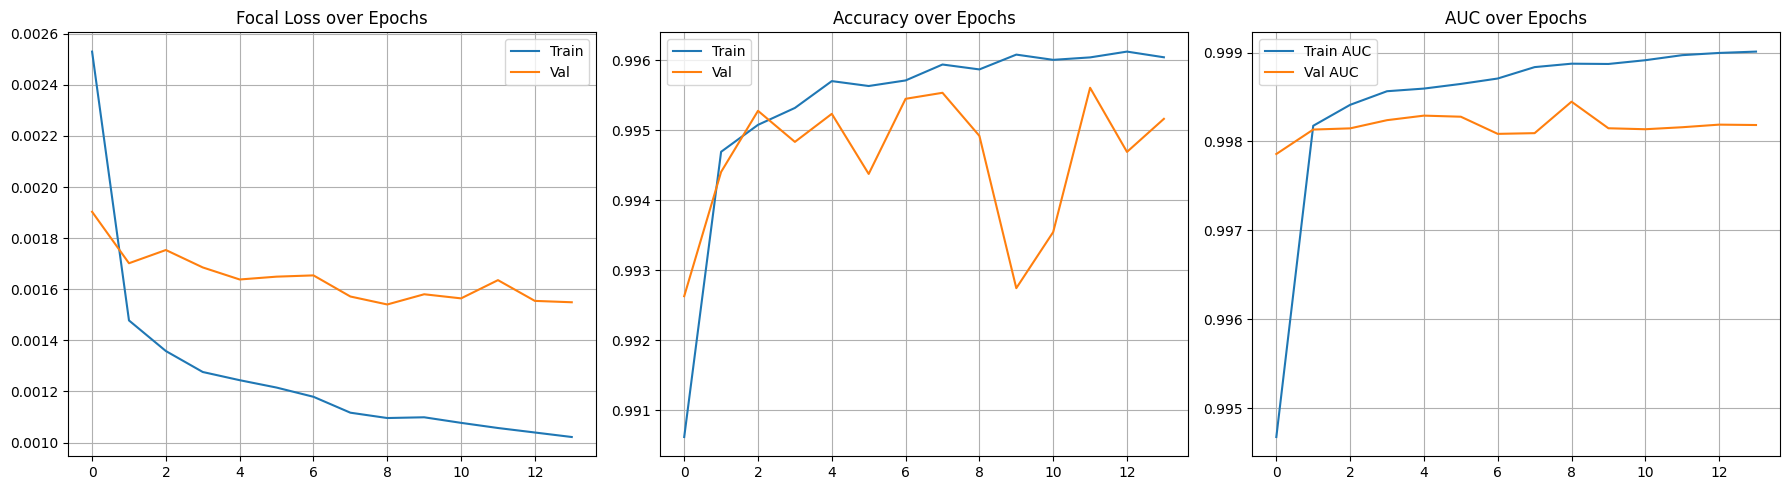

In [ ]:

 
# =============================================================================
# 9. Training Curves
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Focal Loss over Epochs')
axes[0].legend(); axes[0].grid(True)
 
axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy over Epochs')
axes[1].legend(); axes[1].grid(True)
 
axes[2].plot(history.history['auc'],     label='Train AUC')
axes[2].plot(history.history['val_auc'], label='Val AUC')
axes[2].set_title('AUC over Epochs')
axes[2].legend(); axes[2].grid(True)
 
plt.tight_layout()
plt.savefig('training_curves_v3.png', dpi=150)
plt.show()

5459/5459 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step

✅ Best Threshold : 0.5482
✅ Best F1-Score  : 0.9005


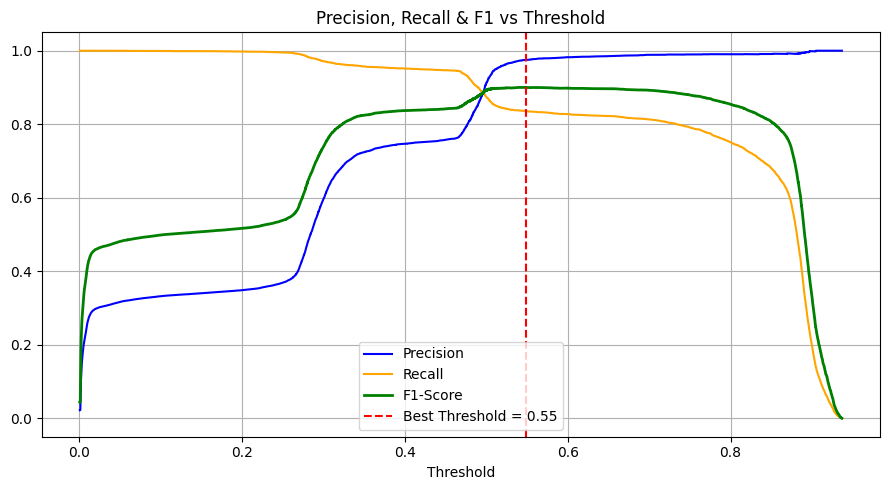

In [ ]:
# =============================================================================
# 10. Threshold Tuning
# =============================================================================
y_pred_prob = model.predict(X_test).flatten()
 
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)
f1_scores   = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx        = np.argmax(f1_scores)
best_threshold  = thresholds[best_idx]
 
print(f"\n Best Threshold : {best_threshold:.4f}")
print(f" Best F1-Score  : {f1_scores[best_idx]:.4f}")
 
plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue')
plt.plot(thresholds, recalls[:-1],    label='Recall',    color='orange')
plt.plot(thresholds, f1_scores,       label='F1-Score',  color='green', lw=2)
plt.axvline(x=best_threshold, color='red', linestyle='--',
            label=f'Best Threshold = {best_threshold:.2f}')
plt.xlabel('Threshold'); plt.title('Precision, Recall & F1 vs Threshold')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig('threshold_v3.png', dpi=150)
plt.show()


--- Final Classification Report ---
                       precision    recall  f1-score   support

           Normal (0)       1.00      1.00      1.00    170758
High Risk / Maint (1)       0.97      0.84      0.90      3909

             accuracy                           1.00    174667
            macro avg       0.99      0.92      0.95    174667
         weighted avg       1.00      1.00      1.00    174667

ROC-AUC Score : 0.9985
Macro F1      : 0.9492

📊 Comparison:
  v2 ROC-AUC  = 0.6764  →  v3 ROC-AUC  = 0.9985
  v2 Macro F1 = 0.5857  →  v3 Macro F1 = 0.9492


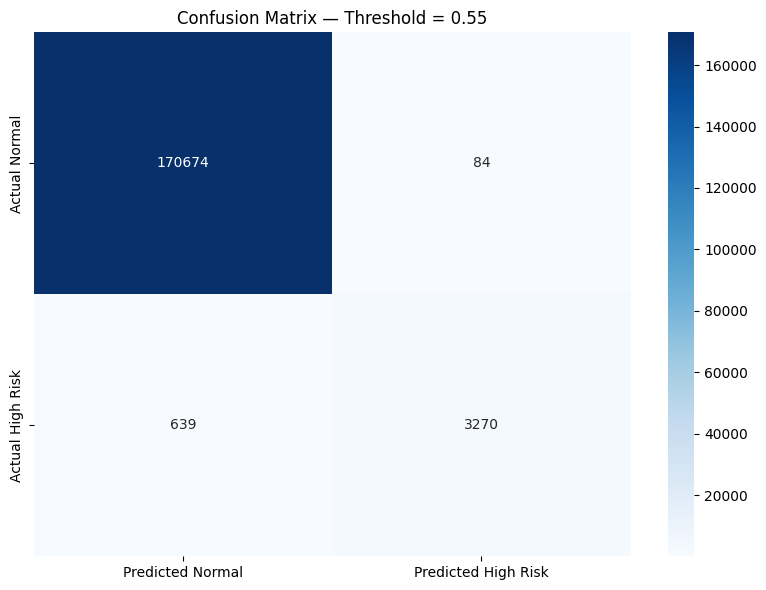

In [ ]:

 # =============================================================================
# 11.final evaluation
# =============================================================================
y_pred = (y_pred_prob >= best_threshold).astype(int)
 
print("\n" + "="*60)
print("--- Final Classification Report ---")
print("="*60)
print(classification_report(y_test, y_pred,
      target_names=['Normal (0)', 'High Risk / Maint (1)']))
 
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC Score : {roc_auc:.4f}")
print(f"Macro F1      : {f1_score(y_test, y_pred, average='macro'):.4f}")
 
# مقارنة مع v2
print(f"\n Comparison:")
print(f"  v2 ROC-AUC  = 0.6764  →  v3 ROC-AUC  = {roc_auc:.4f}")
print(f"  v2 Macro F1 = 0.5857  →  v3 Macro F1 = {f1_score(y_test, y_pred, average='macro'):.4f}")
 
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted High Risk'],
            yticklabels=['Actual Normal', 'Actual High Risk'])
plt.title(f'Confusion Matrix — Threshold = {best_threshold:.2f}')
plt.tight_layout()
plt.savefig('confusion_matrix_v3.png', dpi=150)
plt.show()

In [ ]:
# =============================================================================
# 12. saving model and artifacts
# =============================================================================
model.save('aviation_maintenance_v3.keras')
joblib.dump(scaler, 'scaler_v3.pkl')
np.save('best_threshold_v3.npy', best_threshold)
joblib.dump(top_features, 'top_features_v3.pkl')

print("\n Saved: aviation_maintenance_v3.keras")
print(" Saved: scaler_v3.pkl")
print(" Saved: best_threshold_v3.npy")
print(" Saved: top_features_v3.pkl")


✅ Saved: aviation_maintenance_v3.keras
✅ Saved: scaler_v3.pkl
✅ Saved: best_threshold_v3.npy
✅ Saved: top_features_v3.pkl
